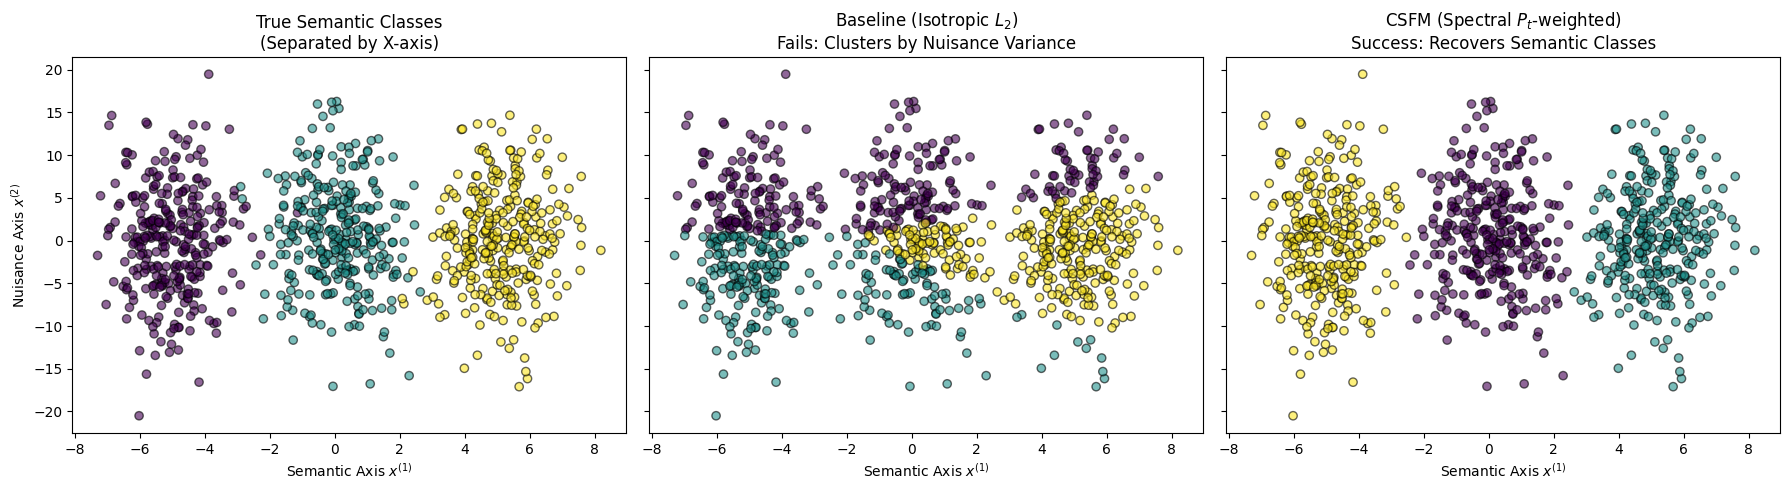

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# ==========================================
# 1. Generate the 2D Synthetic Dataset
# ==========================================
np.random.seed(42)
N_per_class = 300

# Semantic classes separated along the x-axis (Semantic Subspace)
# Massive variance along the y-axis (Nuisance Subspace)
mu_1 = [-5, 0]
mu_2 = [0, 0]
mu_3 = [5, 0]

# Covariance: Small semantic variance (1), Huge nuisance variance (40)
cov = [[1, 0], 
       [0, 40]]

# Generate data points
X1 = np.random.multivariate_normal(mu_1, cov, N_per_class)
X2 = np.random.multivariate_normal(mu_2, cov, N_per_class)
X3 = np.random.multivariate_normal(mu_3, cov, N_per_class)

X = np.vstack((X1, X2, X3))
y_true = np.array([0]*N_per_class + [1]*N_per_class + [2]*N_per_class)

# ==========================================
# 2. Baseline: Isotropic DRL (Standard L2 K-Means)
# ==========================================
# The baseline penalizes uniformly across all dimensions.
kmeans_baseline = KMeans(n_clusters=3, random_state=42, n_init=10)
y_baseline = kmeans_baseline.fit_predict(X)

# ==========================================
# 3. CSFM: Spectral Projection (Pt-weighted K-Means)
# ==========================================
# In CSFM, the degradation operator destroys the nuisance axis.
# The integrated penalty matrix P_t heavily penalizes semantic errors 
# and ignores nuisance errors.
P_eff = np.array([[1.0, 0.0], 
                  [0.0, 0.01]])  # 1% penalty for the nuisance axis

# To implement Mahalanobis K-means efficiently, we transform the data 
# using the square root of P_eff, run standard K-means, and map back.
L = np.sqrt(P_eff)
X_csfm_projected = X.dot(L)

kmeans_csfm = KMeans(n_clusters=3, random_state=42, n_init=10)
y_csfm = kmeans_csfm.fit_predict(X_csfm_projected)

# ==========================================
# 4. Visualization
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

# Plot 1: True Semantic Classes
axs[0].scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis', alpha=0.6, edgecolors='k')
axs[0].set_title("True Semantic Classes\n(Separated by X-axis)")
axs[0].set_xlabel("Semantic Axis $x^{(1)}$")
axs[0].set_ylabel("Nuisance Axis $x^{(2)}$")

# Plot 2: Baseline (L2) Collapse
axs[1].scatter(X[:, 0], X[:, 1], c=y_baseline, cmap='viridis', alpha=0.6, edgecolors='k')
axs[1].set_title("Baseline (Isotropic $L_2$)\nFails: Clusters by Nuisance Variance")
axs[1].set_xlabel("Semantic Axis $x^{(1)}$")

# Plot 3: CSFM Success
axs[2].scatter(X[:, 0], X[:, 1], c=y_csfm, cmap='viridis', alpha=0.6, edgecolors='k')
axs[2].set_title("CSFM (Spectral $P_t$-weighted)\nSuccess: Recovers Semantic Classes")
axs[2].set_xlabel("Semantic Axis $x^{(1)}$")

plt.tight_layout()
plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
from scipy.stats import ortho_group
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. Generate High-Dimensional Mixed Dataset
# ==========================================
np.random.seed(42)
N_per_class = 200
K = 3
D = 64
d_sem = 4   # Semantic subspace dimensions
d_nuis = 60 # Nuisance subspace dimensions

# True cluster centroids in the semantic subspace
mu_1 = np.random.normal(loc=-5, scale=1, size=d_sem)
mu_2 = np.random.normal(loc=0, scale=1, size=d_sem)
mu_3 = np.random.normal(loc=5, scale=1, size=d_sem)

# Generate latent data W = [Semantic, Nuisance]
W_sem_1 = np.random.multivariate_normal(mu_1, np.eye(d_sem), N_per_class)
W_sem_2 = np.random.multivariate_normal(mu_2, np.eye(d_sem), N_per_class)
W_sem_3 = np.random.multivariate_normal(mu_3, np.eye(d_sem), N_per_class)
W_sem = np.vstack((W_sem_1, W_sem_2, W_sem_3))

# Massive variance injected into the nuisance subspace
W_nuis = np.random.multivariate_normal(np.zeros(d_nuis), 50.0 * np.eye(d_nuis), N_per_class * K)
W_latent = np.hstack((W_sem, W_nuis))

# Entangle features using a random orthogonal matrix (Simulating UDCT x P_YUV)
R = ortho_group.rvs(dim=D, random_state=42)
X_obs = W_latent.dot(R.T) 
y_true = np.array([0]*N_per_class + [1]*N_per_class + [2]*N_per_class)

# ==========================================
# 2. Baseline: Isotropic DRL (L2 K-Means)
# ==========================================
# Baseline applies standard K-means directly on the entangled observation space
kmeans_base = KMeans(n_clusters=K, random_state=42)
y_base = kmeans_base.fit_predict(X_obs)

# ==========================================
# 3. CSFM: Time-Integrated Spectral K-Means
# ==========================================
T_steps = 20
t_vals = np.linspace(0.01, 0.99, T_steps)
dt = t_vals[1] - t_vals[0]

P_eff_diag = np.zeros(D)

for t in t_vals:
    # --- Semantic Schedule (Standard Cosine) ---
    alpha_sem = np.cos(np.pi / 2 * t)
    sigma_sem = np.sin(np.pi / 2 * t)
    d_alpha_sem = -(np.pi / 2) * np.sin(np.pi / 2 * t)
    lambda_sem = d_alpha_sem / (sigma_sem**2 + 1e-8) # Derived simplification
    
    # --- Nuisance Schedule (Time-Warped, fast decay) ---
    # Decays to 0 quickly (by t ~ 0.33), then derivative is 0
    t_warped = min(1.0, t * 3.0) 
    alpha_nuis = np.cos(np.pi / 2 * t_warped)
    sigma_nuis = np.sin(np.pi / 2 * t_warped)
    d_alpha_nuis = -(np.pi / 2 * 3.0) * np.sin(np.pi / 2 * t_warped) if t < 0.33 else 0.0
    lambda_nuis = d_alpha_nuis / (sigma_nuis**2 + 1e-8)
    
    # Construct P_t diagonal = (Lambda_t)^2
    Pt_diag = np.concatenate([
        np.full(d_sem, lambda_sem**2),
        np.full(d_nuis, lambda_nuis**2)
    ])
    
    # Riemann Sum Integration: Accumulate P_t * dt
    P_eff_diag += Pt_diag * dt

# Project data using the integrated metric
# Dist = (X R^T - Y R^T)^T P_eff (X R^T - Y R^T)
L_eff = np.sqrt(P_eff_diag)
X_csfm_proj = X_obs.dot(R) * L_eff

kmeans_csfm = KMeans(n_clusters=K, random_state=42)
y_csfm = kmeans_csfm.fit_predict(X_csfm_proj)

# ==========================================
# 4. Evaluation
# ==========================================
def map_labels(y_true, y_pred):
    """Maps arbitrary K-means labels to true labels to calculate accuracy."""
    from scipy.optimize import linear_sum_assignment
    confusion_matrix = np.zeros((K, K), dtype=int)
    for t, p in zip(y_true, y_pred):
        confusion_matrix[t, p] += 1
    row_ind, col_ind = linear_sum_assignment(-confusion_matrix)
    mapping = {col_ind[i]: row_ind[i] for i in range(K)}
    return np.array([mapping[p] for p in y_pred])

acc_base = accuracy_score(y_true, map_labels(y_true, y_base))
acc_csfm = accuracy_score(y_true, map_labels(y_true, y_csfm))

print("=== High-Dimensional Clustering Results (D=64) ===")
print(f"Baseline (Isotropic DRL) Accuracy : {acc_base * 100:.2f}%")
print(f"CSFM (Spectral Projection) Accuracy: {acc_csfm * 100:.2f}%")

=== High-Dimensional Clustering Results (D=64) ===
Baseline (Isotropic DRL) Accuracy : 38.83%
CSFM (Spectral Projection) Accuracy: 38.83%


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import scipy.fftpack
import torchvision
import torchvision.transforms as transforms
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. Load and Prepare Downsampled CIFAR-10
# ==========================================
print("Loading CIFAR-10 and downsampling to 16x16...")
transform = transforms.Compose([
    transforms.Resize((16, 16)),
    transforms.ToTensor()
])
dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# Select 3 distinct classes: 0 (Airplane), 1 (Automobile), 8 (Ship)
classes_to_keep = [0, 1, 8]
N_per_class = 200 # 600 total images
X_raw = []
y_true = []
counts = {c: 0 for c in classes_to_keep}

for img, label in dataset:
    if label in classes_to_keep and counts[label] < N_per_class:
        X_raw.append(img.numpy()) # Shape: (3, 16, 16)
        y_true.append(label)
        counts[label] += 1
    if all(v == N_per_class for v in counts.values()):
        break

X_raw = np.array(X_raw)
y_true = np.array([ {0:0, 1:1, 8:2}[l] for l in y_true ])

# ==========================================
# 2. Spectral Operators & Basis Projection
# ==========================================
# W matrix: Orthonormal RGB to YUV (Opponent Color Space)
W = np.array([
    [1/np.sqrt(3),  1/np.sqrt(3),  1/np.sqrt(3)],
    [1/np.sqrt(2), -1/np.sqrt(2),  0],
    [1/np.sqrt(6),  1/np.sqrt(6), -2/np.sqrt(3)]
])

print("Projecting data into Joint Eigenbasis (YUV + 2D DCT)...")
X_spectral = np.zeros_like(X_raw)
for i in range(len(X_raw)):
    # 1. Apply W to channels: (3, 16, 16)
    img_yuv = np.tensordot(W, X_raw[i], axes=([1], [0]))
    # 2. Apply 2D DCT to each channel
    img_dct = scipy.fftpack.dctn(img_yuv, axes=(1, 2), norm='ortho')
    X_spectral[i] = img_dct

# Flatten for K-Means: (N, 768)
X_spectral_flat = X_spectral.reshape(len(X_spectral), -1)
X_raw_flat = X_raw.reshape(len(X_raw), -1)

# ==========================================
# 3. Time-Integrated Projection (CSFM P_eff)
#    LINEAR SCHEDULE: gamma(t) = t
# ==========================================
print("Integrating analytical P_eff using Linear & Gaussian Blur schedules...")
T_steps = 100
t_vals = np.linspace(0.01, 0.99, T_steps)
dt = t_vals[1] - t_vals[0]

# k_blur acts as the spatial difficulty multiplier
k_blur = 15.0 

P_eff_diag = np.zeros((3, 16, 16))

# Precompute normalized ||f||^2 matrix for the 16x16 DCT grid
f_norm_sq = np.zeros((16, 16))
for fx in range(16):
    for fy in range(16):
        f_norm_sq[fx, fy] = (fx**2 + fy**2) / (15**2 + 15**2)

for t in t_vals:
    # --- MODIFICATION: Linear Time Warping ---
    gamma_t = t
    d_gamma_t = 1.0 
    
    # VP Schedule Alpha
    alpha_t = np.cos(np.pi / 2 * gamma_t)
    d_alpha_t = -(np.pi / 2) * np.sin(np.pi / 2 * gamma_t) * d_gamma_t
    
    # Frequency Gaussian Kernel
    M_f = np.exp(-k_blur * gamma_t * f_norm_sq)
    d_M_f = M_f * (-k_blur * d_gamma_t * f_norm_sq)
    
    for c in range(3):
        if c == 0:
            # Luminance (Y): Decayed by frequency mask only
            alpha_eff = alpha_t * M_f
            d_alpha_eff = d_alpha_t * M_f + alpha_t * d_M_f
        else:
            # Chroma (U, V): Decayed by color operator AND frequency mask
            alpha_eff = (alpha_t**2) * M_f
            d_alpha_eff = 2 * alpha_t * d_alpha_t * M_f + (alpha_t**2) * d_M_f
            
        sigma_eff_sq = 1 - alpha_eff**2
        
        # Projection weight lambda(t)
        lambda_t = d_alpha_eff / (sigma_eff_sq + 1e-8)
        P_eff_diag[c] += (lambda_t**2) * dt

P_eff_flat = P_eff_diag.reshape(-1)
# ==========================================
# 4. Optimal Encoder Clustering Evaluation
# ==========================================
print("Evaluating L2 Baseline vs. Spectral CSFM...")
K_clusters = 3

# Baseline: Uniform L2 on raw pixels (OT Path)
kmeans_base = KMeans(n_clusters=K_clusters, random_state=42, n_init=20)
y_base = kmeans_base.fit_predict(X_raw_flat)

# CSFM: Spectral Projection 
# Scale spectral data by the square root of integrated P_eff
X_csfm_projected = X_spectral_flat * np.sqrt(P_eff_flat)
kmeans_csfm = KMeans(n_clusters=K_clusters, random_state=42, n_init=20)
y_csfm = kmeans_csfm.fit_predict(X_csfm_projected)

# --- Alignment & Scoring Utility ---
def align_labels(y_true, y_pred):
    from scipy.optimize import linear_sum_assignment
    cm = np.zeros((K_clusters, K_clusters), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col_ind[i]: row_ind[i] for i in range(K_clusters)}
    return np.array([mapping[p] for p in y_pred])

acc_base = accuracy_score(y_true, align_labels(y_true, y_base))
acc_csfm = accuracy_score(y_true, align_labels(y_true, y_csfm))

print("\n=== Analytical Encoder Results (CIFAR-10 16x16) ===")
print(f"Baseline (Isotropic OT) Accuracy : {acc_base * 100:.2f}%")
print(f"CSFM (Spectral Projection) Accuracy: {acc_csfm * 100:.2f}%")

Loading CIFAR-10 and downsampling to 16x16...
Files already downloaded and verified
Projecting data into Joint Eigenbasis (YUV + 2D DCT)...
Integrating analytical P_eff using Linear & Gaussian Blur schedules...
Evaluating L2 Baseline vs. Spectral CSFM...

=== Analytical Encoder Results (CIFAR-10 16x16) ===
Baseline (Isotropic OT) Accuracy : 52.50%
CSFM (Spectral Projection) Accuracy: 51.33%


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import scipy.fftpack
import torchvision
import torchvision.transforms as transforms
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. Load and Prepare Downsampled CIFAR-10
# ==========================================
print("Loading CIFAR-10 and downsampling to 16x16...")
transform = transforms.Compose([
    transforms.Resize((16, 16)),
    transforms.ToTensor()
])
dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# Select 3 distinct classes: 0 (Airplane), 1 (Automobile), 8 (Ship)
classes_to_keep = [0, 1, 8]
N_per_class = 200 # 600 total images
X_raw = []
y_true = []
counts = {c: 0 for c in classes_to_keep}

for img, label in dataset:
    if label in classes_to_keep and counts[label] < N_per_class:
        X_raw.append(img.numpy()) # Shape: (3, 16, 16)
        y_true.append(label)
        counts[label] += 1
    if all(v == N_per_class for v in counts.values()):
        break

X_raw = np.array(X_raw)
y_true = np.array([ {0:0, 1:1, 8:2}[l] for l in y_true ])

# ==========================================
# 2. Spectral Operators & Basis Projection
# ==========================================
# W matrix: Orthonormal RGB to YUV (Opponent Color Space)
W = np.array([
    [1/np.sqrt(3),  1/np.sqrt(3),  1/np.sqrt(3)],
    [1/np.sqrt(2), -1/np.sqrt(2),  0],
    [1/np.sqrt(6),  1/np.sqrt(6), -2/np.sqrt(3)]
])

print("Projecting data into Joint Eigenbasis (YUV + 2D DCT)...")
X_spectral = np.zeros_like(X_raw)
for i in range(len(X_raw)):
    img_yuv = np.tensordot(W, X_raw[i], axes=([1], [0]))
    img_dct = scipy.fftpack.dctn(img_yuv, axes=(1, 2), norm='ortho')
    X_spectral[i] = img_dct

X_spectral_flat = X_spectral.reshape(len(X_spectral), -1)
X_raw_flat = X_raw.reshape(len(X_raw), -1)

# ==========================================
# 3. Time-Integrated Projection (CSFM P_eff)
#    LINEAR SCHEDULE & STABLE WEIGHTING
# ==========================================
print("Integrating analytical P_eff using Stable Simple Objective Weighting...")
T_steps = 100
t_vals = np.linspace(0.01, 0.99, T_steps)
dt = t_vals[1] - t_vals[0]

# Reduced k_blur for 16x16 to preserve macro structures
k_blur = 15.0 

P_eff_diag = np.zeros((3, 16, 16))

f_norm_sq = np.zeros((16, 16))
for fx in range(16):
    for fy in range(16):
        f_norm_sq[fx, fy] = (fx**2 + fy**2) / (15**2 + 15**2)

for t in t_vals:
    gamma_t = t
    d_gamma_t = 1.0 
    
    alpha_t = np.cos(np.pi / 2 * gamma_t)
    d_alpha_t = -(np.pi / 2) * np.sin(np.pi / 2 * gamma_t) * d_gamma_t
    
    M_f = np.exp(-k_blur * gamma_t * f_norm_sq)
    d_M_f = M_f * (-k_blur * d_gamma_t * f_norm_sq)
    
    for c in range(3):
        if c == 0:
            # Luminance (Y)
            d_alpha_eff = d_alpha_t * M_f + alpha_t * d_M_f
        else:
            # Chroma (U, V)
            d_alpha_eff = 2 * alpha_t * d_alpha_t * M_f + (alpha_t**2) * d_M_f
            
        # FIX: Using stable (d_alpha_eff)^2 weighting to prevent t->0 singularity
        P_eff_diag[c] += (d_alpha_eff**2) * dt

P_eff_flat = P_eff_diag.reshape(-1)

# ==========================================
# 4. Optimal Encoder Clustering Evaluation
# ==========================================
print("Evaluating L2 Baseline vs. Spectral CSFM...")
K_clusters = 3

kmeans_base = KMeans(n_clusters=K_clusters, random_state=42, n_init=20)
y_base = kmeans_base.fit_predict(X_raw_flat)

# Scale spectral data by the square root of integrated P_eff
X_csfm_projected = X_spectral_flat * np.sqrt(P_eff_flat)
kmeans_csfm = KMeans(n_clusters=K_clusters, random_state=42, n_init=20)
y_csfm = kmeans_csfm.fit_predict(X_csfm_projected)

def align_labels(y_true, y_pred):
    from scipy.optimize import linear_sum_assignment
    cm = np.zeros((K_clusters, K_clusters), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col_ind[i]: row_ind[i] for i in range(K_clusters)}
    return np.array([mapping[p] for p in y_pred])

acc_base = accuracy_score(y_true, align_labels(y_true, y_base))
acc_csfm = accuracy_score(y_true, align_labels(y_true, y_csfm))

print("\n=== Analytical Encoder Results (CIFAR-10 16x16) ===")
print(f"Baseline (Isotropic OT) Accuracy : {acc_base * 100:.2f}%")
print(f"CSFM (Spectral Projection) Accuracy: {acc_csfm * 100:.2f}%")

Loading CIFAR-10 and downsampling to 16x16...
Files already downloaded and verified
Projecting data into Joint Eigenbasis (YUV + 2D DCT)...
Integrating analytical P_eff using Stable Simple Objective Weighting...
Evaluating L2 Baseline vs. Spectral CSFM...

=== Analytical Encoder Results (CIFAR-10 16x16) ===
Baseline (Isotropic OT) Accuracy : 52.50%
CSFM (Spectral Projection) Accuracy: 52.33%


In [12]:
import numpy as np
import scipy.fftpack
import torchvision
import torchvision.transforms as transforms
from scipy.special import softmax
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# 1. Load Data & Project to Eigenbasis
# ==========================================
transform = transforms.Compose([transforms.Resize((16, 16)), transforms.ToTensor()])
dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
classes_to_keep = [0, 1, 8]
N_per_class = 50

X_raw, y_true, counts = [], [], {c: 0 for c in classes_to_keep}
for img, label in dataset:
    if label in classes_to_keep and counts[label] < N_per_class:
        X_raw.append(img.numpy())
        y_true.append(label)
        counts[label] += 1
    if all(v == N_per_class for v in counts.values()): break

X_raw = np.array(X_raw)
y_true = np.array([ {0:0, 1:1, 8:2}[l] for l in y_true ])

W = np.array([[1/np.sqrt(3), 1/np.sqrt(3), 1/np.sqrt(3)],
              [1/np.sqrt(2), -1/np.sqrt(2), 0],
              [1/np.sqrt(6), 1/np.sqrt(6), -2/np.sqrt(3)]])

X_spectral = np.zeros_like(X_raw)
for i in range(len(X_raw)):
    img_yuv = np.tensordot(W, X_raw[i], axes=([1], [0]))
    X_spectral[i] = scipy.fftpack.dctn(img_yuv, axes=(1, 2), norm='ortho')

X = X_spectral.reshape(len(X_spectral), -1)
N, D = X.shape
K_clusters = 3

# ==========================================
# 2. Precompute Exact Subspace Operators
# ==========================================
T_steps = 20 # Number of Monte Carlo time integration steps
t_vals = np.linspace(0.01, 0.99, T_steps)
dt = t_vals[1] - t_vals[0]
k_blur = 5.0 

alpha_eff_t = np.zeros((T_steps, D))
sigma_eff_t = np.zeros((T_steps, D))
Pt_diag_t = np.zeros((T_steps, D))

f_norm_sq = np.zeros((16, 16))
for fx in range(16):
    for fy in range(16): f_norm_sq[fx, fy] = (fx**2 + fy**2) / (15**2 + 15**2)
f_norm_sq = f_norm_sq.flatten()

for idx, t in enumerate(t_vals):
    gamma_t = t
    alpha_t = np.cos(np.pi / 2 * gamma_t)
    d_alpha_t = -(np.pi / 2) * np.sin(np.pi / 2 * gamma_t)
    
    M_f = np.exp(-k_blur * gamma_t * f_norm_sq)
    d_M_f = M_f * (-k_blur * f_norm_sq)
    
    alpha_eff_t[idx, :256] = alpha_t * M_f
    d_alpha_eff = d_alpha_t * M_f + alpha_t * d_M_f
    Pt_diag_t[idx, :256] = d_alpha_eff**2
    
    alpha_eff_t[idx, 256:] = (alpha_t**2) * np.tile(M_f, 2)
    d_alpha_eff = 2 * alpha_t * d_alpha_t * np.tile(M_f, 2) + (alpha_t**2) * np.tile(d_M_f, 2)
    Pt_diag_t[idx, 256:] = d_alpha_eff**2
    
    sigma_eff_t[idx, :] = np.sqrt(np.clip(1 - alpha_eff_t[idx, :]**2, 1e-8, 1.0))

# ==========================================
# 3. Exact Monte Carlo Combinatorial Solver
# ==========================================
print("Running Exact Discrete Posterior Solver (No Approximations)...")

# Initialize random assignments
np.random.seed(42)
assignments = np.random.randint(0, K_clusters, N)

N_MC_samples = 3 # Monte Carlo noise samples per point per timestep

for iteration in range(5):
    new_assignments = np.copy(assignments)
    total_reassigned = 0
    
    for i in range(N):
        x_0_i = X[i]
        best_k = assignments[i]
        min_expected_loss = float('inf')
        
        # Test assigning point i to each cluster k
        for k in range(K_clusters):
            # The cluster subset (including point i to test the hypothetical cost)
            cluster_indices = np.where(assignments == k)[0]
            if i not in cluster_indices:
                cluster_indices = np.append(cluster_indices, i)
            
            X_cluster = X[cluster_indices]
            if len(X_cluster) == 0: continue
            
            cluster_loss = 0.0
            
            # Monte Carlo Integration over time
            for idx, t in enumerate(t_vals):
                M_t = alpha_eff_t[idx]
                C_t_inv = 1.0 / (sigma_eff_t[idx]**2 + 1e-8)
                P_t = Pt_diag_t[idx]
                
                # Monte Carlo expectation over noise
                for _ in range(N_MC_samples):
                    noise = np.random.randn(D)
                    # Simulate noisy state for point i
                    x_t = M_t * x_0_i + sigma_eff_t[idx] * noise
                    
                    # 1. Exact Mahalanobis Distances to all points in cluster
                    # (x_t - M_t * x_cluster)^T * C_t_inv * (x_t - M_t * x_cluster)
                    diffs = x_t - M_t * X_cluster
                    mahalanobis_dists = np.sum((diffs**2) * C_t_inv, axis=1)
                    
                    # 2. Exact Discrete Posterior (Softmax)
                    w_j = softmax(-0.5 * mahalanobis_dists)
                    
                    # 3. Exact Posterior Mean
                    x_hat_0 = np.sum(w_j[:, None] * X_cluster, axis=0)
                    
                    # 4. Exact P_t-Projected Posterior Variance
                    # sum( w_j * (X_j - x_hat)^T P_t (X_j - x_hat) )
                    proj_variance = np.sum(w_j * np.sum(((X_cluster - x_hat_0)**2) * P_t, axis=1))
                    
                    cluster_loss += proj_variance * dt / N_MC_samples

            if cluster_loss < min_expected_loss:
                min_expected_loss = cluster_loss
                best_k = k
                
        if best_k != assignments[i]:
            new_assignments[i] = best_k
            total_reassigned += 1
            
    assignments = np.copy(new_assignments)
    print(f"Iteration {iteration+1}: {total_reassigned} points reassigned.")
    if total_reassigned == 0:
        print("Converged to exact optimal discrete representation!")
        break

# ==========================================
# 4. Evaluation
# ==========================================
def align_labels(y_true, y_pred):
    from scipy.optimize import linear_sum_assignment
    cm = np.zeros((K_clusters, K_clusters), dtype=int)
    for t, p in zip(y_true, y_pred): cm[t, p] += 1
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col_ind[i]: row_ind[i] for i in range(K_clusters)}
    return np.array([mapping[p] for p in y_pred])

acc = accuracy_score(y_true, align_labels(y_true, assignments))
print(f"\nExact General CSFM Accuracy: {acc * 100:.2f}%")

Files already downloaded and verified
Running Exact Discrete Posterior Solver (No Approximations)...
Iteration 1: 102 points reassigned.
Iteration 2: 121 points reassigned.
Iteration 3: 150 points reassigned.
Iteration 4: 150 points reassigned.
Iteration 5: 150 points reassigned.

Exact General CSFM Accuracy: 33.33%
